# CNN + BiGRU + Attention (Approach 4 of 5)

A hybrid architecture: 1D convolutions over word embeddings pick up local n-gram
patterns (negation + verb, fixed phrases like "anti vax" or "cause autism" — see EDA
finding #11 on sentiment-bearing bigrams), a bidirectional GRU handles longer-range
context across those local features, and an additive attention layer lets the model
down-weight noisy tokens instead of averaging everything uniformly — directly relevant
to the `#mmr` problem (finding #7) and the fact that all three classes share the same
vocabulary (finding #10), so the model needs to attend to what's actually discriminating
rather than just detecting word presence.

This is a genuinely different architecture from the BiLSTM (`bilstm.ipynb`) — it adds
convolutional feature extraction and explicit attention rather than relying only on a
recurrent encoder's final hidden state.


In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import torch

from preprocessing import LABEL_TO_IDX, CLASS_NAMES
from text_dataset import Vocab, TweetDataset
from models import CNNBiGRUAttention
from train_utils import compute_class_weights, train_model, predict
from eval_utils import evaluate, set_seed

set_seed(42)
torch.set_num_threads(4)
device = 'cpu'

train_df = pd.read_csv('../data/processed/train_split.csv')
val_df = pd.read_csv('../data/processed/val_split.csv')

train_texts = train_df['clean_text'].tolist()
val_texts = val_df['clean_text'].tolist()
train_labels = train_df['label'].map(LABEL_TO_IDX).tolist()
val_labels = val_df['label'].map(LABEL_TO_IDX).tolist()

MAX_LEN = 32
vocab = Vocab(train_texts, min_freq=2, max_size=20000)
print('Vocab size:', len(vocab))

train_ds = TweetDataset(train_texts, train_labels, vocab, max_len=MAX_LEN)
val_ds = TweetDataset(val_texts, val_labels, vocab, max_len=MAX_LEN)
class_weights = compute_class_weights(train_labels)


Vocab size: 6991


## Train

In [2]:
model = CNNBiGRUAttention(
    vocab_size=len(vocab), embed_dim=128, n_filters=64, filter_sizes=(2, 3, 4),
    gru_hidden=96, n_classes=3, pad_idx=vocab.stoi['<pad>'],
)
model, history = train_model(
    model, train_ds, val_ds, class_weights,
    epochs=12, batch_size=64, lr=1e-3, patience=3, device=device,
)


Epoch 1/12 | train_loss=0.9788 val_loss=0.9133 val_macro_f1=0.4685 (17.6s)


Epoch 2/12 | train_loss=0.8199 val_loss=0.8557 val_macro_f1=0.5453 (15.0s)


Epoch 3/12 | train_loss=0.6785 val_loss=0.8656 val_macro_f1=0.5587 (16.0s)


Epoch 4/12 | train_loss=0.5353 val_loss=0.9741 val_macro_f1=0.6164 (18.1s)


Epoch 5/12 | train_loss=0.3808 val_loss=1.2128 val_macro_f1=0.6228 (20.9s)


Epoch 6/12 | train_loss=0.2543 val_loss=1.2589 val_macro_f1=0.6009 (19.1s)


Epoch 7/12 | train_loss=0.1657 val_loss=1.6636 val_macro_f1=0.6023 (18.8s)


Epoch 8/12 | train_loss=0.1509 val_loss=1.8621 val_macro_f1=0.5936 (16.8s)
Early stopping at epoch 8 (no improvement for 3 epochs).


## Training curves

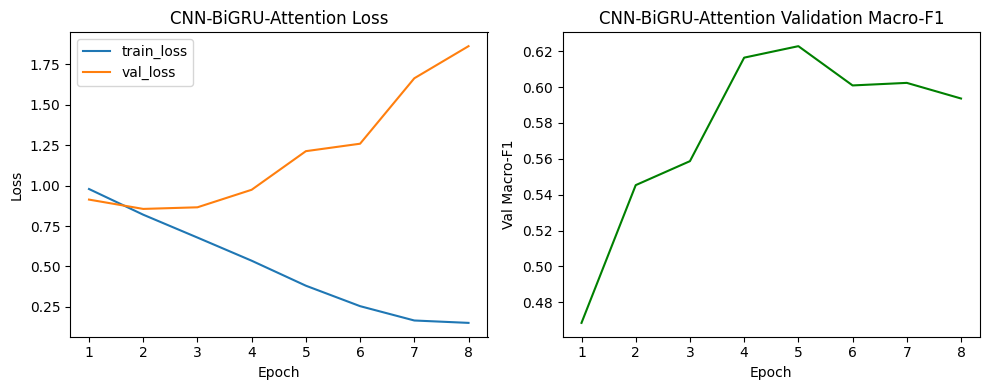

In [3]:
import matplotlib.pyplot as plt
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='train_loss')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'], label='val_loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].set_title('CNN-BiGRU-Attention Loss')
axes[1].plot(hist_df['epoch'], hist_df['val_macro_f1'], color='green')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Macro-F1'); axes[1].set_title('CNN-BiGRU-Attention Validation Macro-F1')
fig.tight_layout()
fig.savefig('../figures/cnn_bigru_training_curves.png', dpi=150)
plt.show()


## Evaluate on validation set

In [4]:
val_preds = predict(model, val_ds, device=device)
result = evaluate(val_labels, val_preds, 'CNN_BiGRU_Attention')



=== CNN_BiGRU_Attention ===
Macro-F1: 0.6228  Weighted-F1: 0.6877  Accuracy: 0.6894
              precision    recall  f1-score   support

    Negative       0.42      0.47      0.44       154
     Neutral       0.72      0.81      0.76       704
    Positive       0.74      0.60      0.66       591

    accuracy                           0.69      1449
   macro avg       0.63      0.63      0.62      1449
weighted avg       0.70      0.69      0.69      1449



## ROC and Precision-Recall curves
One-vs-rest curves from the model's own softmax probabilities. Worth having given the
class imbalance (finding #1) — a confusion matrix alone doesn't show how well-separated
the predicted probabilities actually are.


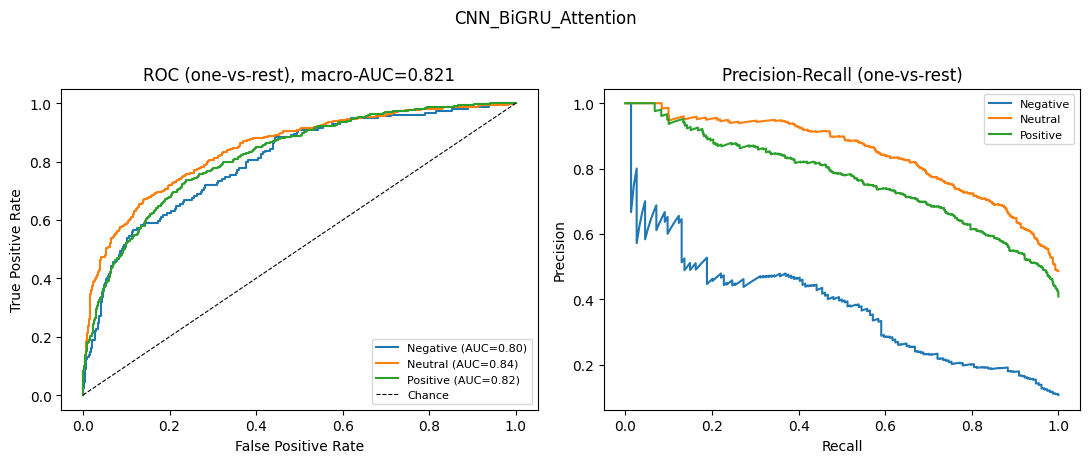

CNN+BiGRU+Attention macro-AUC: 0.8214


In [5]:
from train_utils import predict_proba
from eval_utils import plot_roc_pr

val_proba = predict_proba(model, val_ds, device=device)
macro_auc = plot_roc_pr(val_labels, val_proba, 'CNN_BiGRU_Attention')
print('CNN+BiGRU+Attention macro-AUC:', round(macro_auc, 4))


## Attention weight inspection (qualitative check)
Checking that attention actually concentrates on sentiment-bearing words instead of
spreading out evenly — a look at a few validation examples.


In [6]:
import torch as _torch

def show_attention(text, model, vocab, max_len=32):
    model.eval()
    ids = _torch.tensor([vocab.encode(text, max_len)], dtype=_torch.long)
    mask = (ids != vocab.stoi['<pad>']).float()
    with _torch.no_grad():
        emb = model.embedding(ids).transpose(1, 2)
        conv_outs = [_torch.relu(c(emb)) for c in model.convs]
        min_len = min(c.size(2) for c in conv_outs)
        conv_outs = [c[:, :, :min_len] for c in conv_outs]
        cnn_feat = _torch.cat(conv_outs, dim=1).transpose(1, 2)
        gru_out, _ = model.gru(cnn_feat)
        _, weights = model.attention(gru_out, mask[:, :min_len])
    tokens = text.lower().split()[:min_len]
    w = weights.squeeze(0).tolist()[:len(tokens)]
    for tok, wt in sorted(zip(tokens, w), key=lambda p: -p[1])[:6]:
        print(f'{tok:15s} {wt:.3f}')

for sample in val_df['clean_text'].sample(3, random_state=1).tolist():
    print('\nText:', sample)
    show_attention(sample, model, vocab)



Text: ((ELB)) The next face of measles?: "I am a healthy bouncing baby boy and I could be the next face of measles. I am to young to be vac...
face            0.205
am              0.166
face            0.135
baby            0.116
of              0.072
to              0.050

Text: Perry Was Right on Requiring HPV Vaccine, Schools Should Follow Suit: View - <user> <url>
-               0.263
follow          0.221
suit:           0.115
view            0.069
perry           0.066
on              0.062

Text: .<user> Uh oh. “<user> One in five millennials thinks vaccines cause autism <url> <url>
uh              0.307
oh.             0.196
cause           0.129
autism          0.088
vaccines        0.060
.<user>         0.055


## Summary
Results in `reports/results/CNN_BiGRU_Attention.json`, confusion matrix in
`figures/cm_cnn_bigru_attention.png`, ROC/PR curves in
`figures/roc_pr_cnn_bigru_attention.png`.
